### This notebook is a user interface that allows mouse-click correction on tracked centroid data that may contains missing disks

In [1]:
import pickle
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import glob
import os
import pandas as pd
import cv2
import re
%matplotlib widget

In [ ]:
# ----------------- USER SETTINGS -----------------
circle_sizes = {1: 40, 3: 50}  # 左鍵/右鍵半徑
roi = (250, 1200, 0, 2000)

def camera_align(I): #updated 20250918
    H = np.array([[ 1.00494159e+00,  2.04956421e-02, -1.06058326e+00],
       [-1.91282504e-02,  1.01391972e+00, -3.65225729e+01],
       [-4.45217427e-06,  9.05846769e-07,  1.00000000e+00]])
    height, width = I.shape[:2]
    warped_I = cv2.warpPerspective(I, H, (width, height))
    return warped_I

### Read in exisiting pickle file that needs to be refined
pickle_file = "M:\Archive\Proj_TPE\Disk_traj_files\TPE_20260414A01_N=262x2_e-4rps_e-1fps_steady_e3frames.pkl"
frame_folder = 'N:\PROJ_TPE\TPE_20260414A01_N=262x2_e-4rps_e-1fps_steady_e3frames'
frame_idx = 50 # starting frame for editing
step = 5 # step size for frame iteration in the GUI

Number of frames = 1000


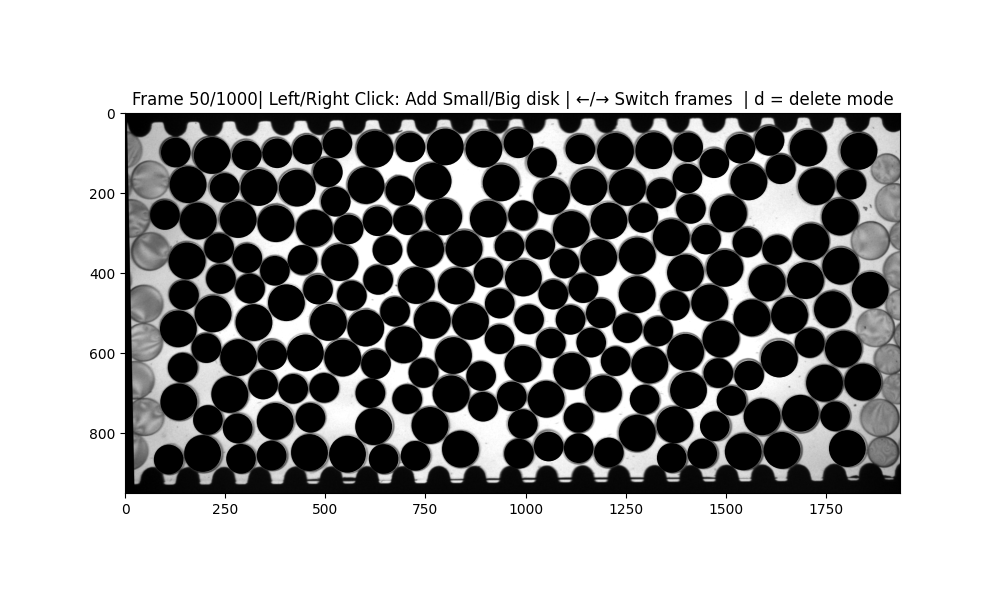

In [ ]:
### Get list of frame files 
def numerical_sort_key(filename):
    # Extract numbers from filename for sorting
    numbers = re.findall(r'\d+', os.path.basename(filename))
    return [int(num) for num in numbers] if numbers else [0]

frame_files = sorted(
    glob.glob(os.path.join(frame_folder, "green_*.png")),
    key=numerical_sort_key
)
n_frames = len(frame_files)

# 讀取 DataFrame
if os.path.exists(pickle_file):
    with open(pickle_file, "rb") as f:
        df = pickle.load(f)   # DataFrame
else:
    df = pd.DataFrame(columns=["frame", "x", "y", "r"])

print('Number of frames = {n_frames}'.format(n_frames=n_frames))

# -------------------------------------------------
# 3. 初始化
fig, ax = plt.subplots(figsize=(10, 6))
delete_mode = False
patches_list = []

# ----------------- 工具函數 -----------------


def save_df():
    with open(pickle_file, "wb") as f:
        pickle.dump(df, f)
    print("Saved to pickle.")

def load_frame(idx):
    global patches_list
    ax.clear()
    patches_list = []

    # 讀影像、裁切、對齊
    img = plt.imread(frame_files[idx])
    img = cv2.flip(img, 1)
    img = camera_align(img)
    # 根據影像維度裁切
    if img.ndim == 3:
        img = img[roi[0]:roi[1], roi[2]:roi[3], 1]
    else:
        img = img[roi[0]:roi[1], roi[2]:roi[3]]
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Frame {idx}/{n_frames}| Left/Right Click: Add Small/Big disk | ←/→ Switch frames  | d = delete mode")

    # 畫出該幀所有圓
    circles = df[df["frame"] == idx]
    for _, row in circles.iterrows():
        circ = patches.Circle((row["x"], row["y"]), row["rpx"], edgecolor="none", facecolor="black")
        ax.add_patch(circ)
        patches_list.append(circ)
    fig.canvas.draw()


# ----------------- 事件處理 -----------------
def onclick(event):
    global df, delete_mode
    if event.inaxes != ax:
        return

    if delete_mode:
        # 刪除模式
        circles = df[df["frame"] == frame_idx]
        if len(circles) == 0:
            print("No circles to delete.")
            delete_mode = False
            return
        x, y = event.xdata, event.ydata
        dists = (circles["x"] - x) ** 2 + (circles["y"] - y) ** 2
        idx_to_del = dists.idxmin()
        df = df.drop(idx_to_del).reset_index(drop=True)
        print(f"Deleted circle at frame {frame_idx}, index {idx_to_del}")
        delete_mode = False
        load_frame(frame_idx)
    else:
        # 新增模式
        if event.button not in circle_sizes:
            return
        r = circle_sizes[event.button]
        x, y = event.xdata, event.ydata
        df = pd.concat([df, pd.DataFrame([{"frame": frame_idx, "x": x, "y": y, "rpx": r}])],
                       ignore_index=True)
        circ = patches.Circle((x, y), r, edgecolor="none", facecolor="black")
        ax.add_patch(circ)
        fig.canvas.draw()
        print(f"Added circle at ({x:.1f},{y:.1f}), r={r}")

def onkey(event):
    global frame_idx, delete_mode
    if event.key == "right":
        save_df()
        frame_idx = min(frame_idx + step, n_frames - step)
        load_frame(frame_idx)
    elif event.key == "left":
        save_df()
        frame_idx = max(frame_idx - step, 0)
        load_frame(frame_idx)
    elif event.key == "d":
        delete_mode = True
        print("Delete mode: click a circle to remove it.")
    elif event.key == "s":
        save_df()


# ----------------- 綁定事件 -----------------
fig.canvas.mpl_connect("button_press_event", onclick)
fig.canvas.mpl_connect("key_press_event", onkey)

# ----------------- 初始化顯示 -----------------
load_frame(frame_idx)
plt.show()

#### Once you're done. Run the next cell to save the corrected df back to the same `.pkl` file, which can then be used for mask generation and model training. The save is overwriting, so edit the filename if you want to keep the original one.

In [3]:

with open(pickle_file, "wb") as f:
        pickle.dump(df, f)
print("Saved to pickle.")

Saved to pickle.
